# Input builder for sequential Gaussian-bump encodings

**Author:** Margot Wagner
**Date:** 2026-04-23

## Purpose
This notebook generates the synthetic input sequences used in the predictive sequence-learning experiments.  
Each time step contains a Gaussian-like activity bump across a population of units, and that bump is shifted across neurons to create a structured sequential input pattern.

## What this notebook does
- defines a small helper for summarizing sparsity/activity
- constructs a Gaussian-bump template
- shifts that template across neurons to form a sequential population code
- downsamples the full sequence to the desired number of time steps
- converts the result to a PyTorch tensor
- optionally saves the tensor and a diagnostic plot

## Output
The main output is `X_mini`, a tensor of shape `(1, T, N)` where:
- `1` = batch dimension
- `T` = number of sampled time steps
- `N` = number of neurons / units

In the experiments shown here, the target is the same as the input:
`Target_mini = X_mini`.

In [1]:
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import torch
from scipy.stats import norm

## Helper function

In [ ]:
def activity_stats(X_mini, threshold: float = 0.5) -> dict:
    """
    Summarize the fraction of active and inactive entries in an encoding matrix.

    Parameters
    ----------
    X_mini : torch.Tensor or np.ndarray
        Encoding array of shape `(1, T, N)` or `(T, N)`.
    threshold : float, default=0.5
        Values greater than or equal to this threshold are counted as active.

    Returns
    -------
    dict
        Dictionary containing:
        - ``frac_active`` : fraction of entries above threshold
        - ``frac_inactive`` : fraction of entries below threshold
        - ``active_inactive_ratio`` : active / inactive ratio
    """
    if isinstance(X_mini, torch.Tensor):
        arr = X_mini.detach().cpu().numpy()
    else:
        arr = np.asarray(X_mini)

    arr = arr.reshape(-1)

    total = arr.size
    active = np.sum(arr >= threshold)
    inactive = total - active

    return {
        "frac_active": float(active / total),
        "frac_inactive": float(inactive / total),
        "active_inactive_ratio": float(active / inactive)
        if inactive > 0
        else float("inf"),
    }

## Build the input sequence

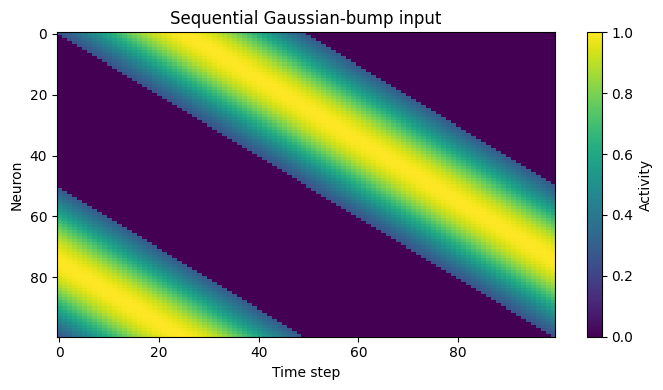

In [6]:
# -----------------------------------------------------------------------------
# Configuration
# -----------------------------------------------------------------------------
output_dir = Path("../data/inputs")

# Number of neurons, number of high-resolution time steps, and number of
# downsampled time steps kept in the final sequence.
N = 100
total_steps = 2000
T = 100

# Set to True to save the tensor and preview figure.
save_outputs = False


# -----------------------------------------------------------------------------
# Build a Gaussian-bump template
# -----------------------------------------------------------------------------
# The template consists of a Gaussian bump followed by zeros. Rolling this
# template across neurons produces a sequential activation pattern.
gaussian_support = np.linspace(norm.ppf(0.05), norm.ppf(0.95), total_steps // 2)
gaussian_bump = norm.pdf(gaussian_support)
template = np.concatenate([gaussian_bump, np.zeros(total_steps // 2)])


# -----------------------------------------------------------------------------
# Shift the template across neurons
# -----------------------------------------------------------------------------
# X_full has shape (N, total_steps): rows are neurons, columns are time points.
X_full = np.zeros((N, total_steps), dtype=np.float32)

shift_per_neuron = total_steps // N
for neuron_idx in range(N):
    X_full[neuron_idx, :] = np.roll(template, neuron_idx * shift_per_neuron)


# -----------------------------------------------------------------------------
# Downsample and normalize
# -----------------------------------------------------------------------------
selected_steps = np.arange(0, total_steps, total_steps // T, dtype=int)

# Final shape: (1, T, N), where the first dimension is batch size.
X_np = np.expand_dims(X_full[:, selected_steps].T, axis=0)
X_np = X_np / X_np.max()

X_mini = torch.tensor(X_np.astype(np.float32))
Target_mini = X_mini


# -----------------------------------------------------------------------------
# Optional save
# -----------------------------------------------------------------------------
if save_outputs:
    output_dir.mkdir(parents=True, exist_ok=True)

    torch.save(
        {"X_mini": X_mini, "Target_mini": Target_mini},
        output_dir / f"Ns{N}_SeqN{T}_asym1.pth.tar",
    )


# -----------------------------------------------------------------------------
# Diagnostic plot
# -----------------------------------------------------------------------------
plt.figure(figsize=(7, 4))
plt.imshow(X_mini[0].T.numpy(), aspect="auto")
plt.colorbar(label="Activity")
plt.title("Sequential Gaussian-bump input")
plt.ylabel("Neuron")
plt.xlabel("Time step")
plt.tight_layout()

if save_outputs:
    plt.savefig(output_dir / f"Ns{N}_SeqN{T}_asym1.png", dpi=300, bbox_inches="tight")

plt.show()

In [7]:
# Activity
stats = activity_stats(X_mini, threshold=0.5)
stats

{'frac_active': 0.35,
 'frac_inactive': 0.65,
 'active_inactive_ratio': 0.5384615384615384}